In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel,Field
from typing import Literal
from IPython.display import Image
from langgraph.checkpoint.memory import InMemorySaver
from langchain.tools import tool

## libs for agents 

from langchain.agents import create_agent
from langchain_community.utilities import GoogleSerperAPIWrapper

c:\Users\TECH DRONA\Desktop\GEN_Ai\env\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [3]:
#coding , google search , weather

class FlowState(BaseModel):
    question : str = Field(description="User Asked Question")
    cetegory : Literal['coding','google_search','weather'] = Field(default="google_search")
    answer : str = Field(default="")

In [4]:
class QestionCategory(BaseModel):
    cetegory : Literal['coding','google_search','weather'] = Field(default="google_search",description="question cetegory")

In [5]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [22]:
### Define Your Agents - google Search Agent , weather Agent

search = GoogleSerperAPIWrapper()

google_agent = create_agent(
    model=llm,
    tools=[search.run],
    # checkpointer=InMemorySaver(),
    system_prompt="you are agent that can search any qustion on google"
)


## wheather tool
@tool
def get_weather(city:str):
    """it provide real time wheather details for any city"""
    # return f"the current temperature in {city} is 23.c"

weather_agent = create_agent(
    model=llm,
    tools=[search.run],    
    system_prompt="you are agent that provide real time wheather details"
)


In [23]:
def check_question_cetegory(state:FlowState) -> FlowState:
    st_llm = llm.with_structured_output(QestionCategory)
    res = st_llm.invoke(f"i want to know the cetegory of my question is : {state.question}, If you are not sure then just give 'google_search' as a cetegory")
    print(res)
    state.cetegory = res.cetegory
    return state

In [24]:
flow = FlowState(question="what is python")
check_question_cetegory(flow)

cetegory='coding'


FlowState(question='what is python', cetegory='coding', answer='')

In [25]:
def route(state:FlowState) -> Literal['coding','google_search','weather']:
    return state.cetegory

In [26]:
def coding_node(state:FlowState) -> FlowState:
    print("coding_node")

    res = llm.invoke(f"you are coding expert: {state.question}")
    state.answer =res.content
    return state



def wheather_node(state:FlowState) -> FlowState:
    res = weather_agent.invoke({"messages":[
        {"role":"user", "content":state.question}
    ]})
    state.answer =res["messages"][-1].content
    print("wheather_node")
    return state


def google_search_node(state:FlowState) -> FlowState:
    res = google_agent.invoke({"messages":[
        {"role":"user", "content":state.question}
    ]})
    state.answer =res["messages"][-1].content

    return state


In [27]:
graph = StateGraph(FlowState)

graph.add_node("check_question_cetegory",check_question_cetegory)
graph.add_node("coding",coding_node)
graph.add_node("google_search",google_search_node)
graph.add_node("weather",wheather_node)

graph.add_edge(START,"check_question_cetegory")
graph.add_conditional_edges("check_question_cetegory",route)
graph.add_edge("coding",END)
graph.add_edge("google_search",END)
graph.add_edge("weather",END)

graph = graph.compile()



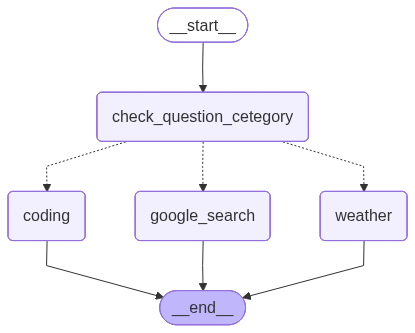

In [28]:
Image(graph.get_graph().draw_mermaid_png())

In [30]:
res = graph.invoke({"question":"what is the temprature in jhansi"})

cetegory='weather'
wheather_node


In [31]:
res

{'question': 'what is the temprature in jhansi',
 'cetegory': 'weather',
 'answer': 'The current temperature in Jhansi is 102°F.'}